In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np

2025-11-14 10:26:46.566057: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-11-14 10:26:46.566127: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-11-14 10:26:46.571575: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
# 加载CIFAR-10数据集（BN 对输入分布敏感，预处理很重要）
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

# 手动数据标准化（像素值从0-255转为0-1）
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# 减去均值
mean = np.mean(x_train, axis=(0, 1, 2))  # 按通道计算均值
x_train -= mean
x_test -= mean

# 标签转为独热编码（分类任务常用）
y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)

# 数据集信息
print(f"训练集：{x_train.shape}, 测试集：{x_test.shape}")

训练集：(50000, 32, 32, 3), 测试集：(10000, 32, 32, 3)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.47179306..0.5495477].


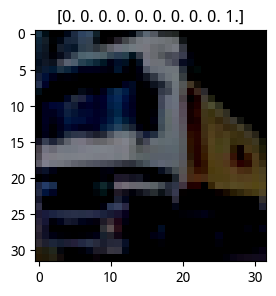

In [3]:
img1=x_train[1]
fig1=plt.figure(figsize=(3,3))
plt.imshow(img1)
plt.title(y_train[1])
plt.show()

In [4]:
# 创建TensorBoard回调
from tensorflow.keras.callbacks import TensorBoard
import datetime

# 模型A的日志目录
log_dir_A = "logs/model_A/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_A = TensorBoard(
    log_dir=log_dir_A,
    histogram_freq=1,
    write_graph=True
)

# 模型B的日志目录
log_dir_B = "logs/model_B/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_B = TensorBoard(
    log_dir=log_dir_B,
    histogram_freq=1,
    write_graph=True
)

# 模型C的日志目录
log_dir_C = "logs/model_C/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_C = TensorBoard(
    log_dir=log_dir_C,
    histogram_freq=1,
    write_graph=True
)

In [5]:
#    基础残差块（Basic Block）
#    x: 输入张量
#    out_channels: 输出通道数
#    stride: 卷积步长（用于下采样）
#    use_bn: 是否使用BatchNormalization


def basic_block(x, out_channels, stride=1, use_bn=True):
    
    residual = x  # 跳跃连接的输入
    
    # 第一个卷积层：3x3卷积 + （可选BN） + ReLU
    x = layers.Conv2D(out_channels, (3, 3), strides=stride, padding='same', use_bias=False)(x)
    if use_bn:
        x = layers.BatchNormalization()(x)  # BN层（训练时自动更新均值/方差）
    x = layers.ReLU()(x)
    
    # 第二个卷积层：3x3卷积 + （可选BN）（无ReLU，激活放在跳跃连接后）
    x = layers.Conv2D(out_channels, (3, 3), strides=1, padding='same', use_bias=False)(x)
    if use_bn:
        x = layers.BatchNormalization()(x)
    
    # 跳跃连接：若输入输出通道数/尺寸不同，用1x1卷积调整
    if stride != 1 or residual.shape[-1] != out_channels:
        residual = layers.Conv2D(out_channels, (1, 1), strides=stride, use_bias=False)(residual)
        if use_bn:
            residual = layers.BatchNormalization()(residual)  # 跳跃连接的输出也需BN
    
    # 残差连接：相加后激活
    x = layers.Add()([x, residual])
    x = layers.ReLU()(x)
    return x

In [6]:
#模型 A：普通 CNN（无残差，无 BN）

def build_simple_cnn():
    
    inputs = layers.Input(shape=(32, 32, 3))
    
    # 特征提取层
    x = layers.Conv2D(16, (3, 3), padding='same')(inputs)
    x = layers.ReLU()(x)
    x = layers.Conv2D(16, (3, 3), padding='same')(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D((2, 2))(x)  # 32x32 → 16x16
    
    x = layers.Conv2D(32, (3, 3), padding='same')(x)
    x = layers.ReLU()(x)
    x = layers.Conv2D(32, (3, 3), padding='same')(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D((2, 2))(x)  # 16x16 → 8x8
    
    x = layers.Conv2D(64, (3, 3), padding='same')(x)
    x = layers.ReLU()(x)
    x = layers.Conv2D(64, (3, 3), padding='same')(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D((2, 2))(x)  # 8x8 → 4x4
    
    # 分类层
    x = layers.Flatten()(x)
    x = layers.Dense(128, activation='relu')(x)
    outputs = layers.Dense(10, activation='softmax')(x)
    
    model = models.Model(inputs=inputs, outputs=outputs)
    return model

In [7]:
#带残差连接（无 BN）

def build_resnet_no_bn():

    inputs = layers.Input(shape=(32, 32, 3))
    
    # 初始卷积层（无BN）
    x = layers.Conv2D(16, (3, 3), padding='same', use_bias=False)(inputs)
    x = layers.ReLU()(x)
    
    # 残差块组（3组，通道数16→32→64）
    x = basic_block(x, 16, stride=1, use_bn=False)  # 不下采样
    x = basic_block(x, 16, stride=1, use_bn=False)
    
    x = basic_block(x, 32, stride=2, use_bn=False)  # 下采样（16x16→8x8）
    x = basic_block(x, 32, stride=1, use_bn=False)
    
    x = basic_block(x, 64, stride=2, use_bn=False)  # 下采样（8x8→4x4）
    x = basic_block(x, 64, stride=1, use_bn=False)
    
    # 分类层（全局平均池化替代Flatten，减少参数）
    x = layers.GlobalAveragePooling2D()(x)
    outputs = layers.Dense(10, activation='softmax')(x)
    
    model = models.Model(inputs=inputs, outputs=outputs)
    return model

In [8]:
#带残差连接 + BN（标准 ResNet）

def build_resnet_with_bn():
    
    inputs = layers.Input(shape=(32, 32, 3))
    
    # 初始卷积层（带BN）
    x = layers.Conv2D(16, (3, 3), padding='same', use_bias=False)(inputs)
    x = layers.BatchNormalization()(x)  # BN层
    x = layers.ReLU()(x)
    
    # 残差块组（3组，通道数16→32→64）
    x = basic_block(x, 16, stride=1, use_bn=True)
    x = basic_block(x, 16, stride=1, use_bn=True)
    
    x = basic_block(x, 32, stride=2, use_bn=True)  # 下采样
    x = basic_block(x, 32, stride=1, use_bn=True)
    
    x = basic_block(x, 64, stride=2, use_bn=True)  # 下采样
    x = basic_block(x, 64, stride=1, use_bn=True)
    
    # 分类层
    x = layers.GlobalAveragePooling2D()(x)
    outputs = layers.Dense(10, activation='softmax')(x)
    
    model = models.Model(inputs=inputs, outputs=outputs)
    return model

In [9]:
#训练模型

def train_model(model, model_name, tensorboard_callback, epochs=20):
    
    # 编译模型（优化器、损失函数、评估指标）
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    # 训练模型（记录历史数据）
    history = model.fit(
        x_train, y_train,
        batch_size=128,
        epochs=epochs,
        validation_data=(x_test, y_test),
        verbose=1,
        callbacks=[tensorboard_callback]
    )
    
    # 保存模型（可选）
    model.save(f'{model_name}.h5')
    return history

In [10]:
# 实例化三种模型
model_A = build_simple_cnn()
model_B = build_resnet_no_bn()
model_C = build_resnet_with_bn()

In [11]:
# 训练模型（分别训练，避免资源冲突，epochs可根据性能调整）
history_A = train_model(model_A, 'model_A', tensorboard_A, epochs=20)

Epoch 1/20


I0000 00:00:1763087213.505765    5495 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


391/391 [==============================] - 7s 10ms/step - loss: 1.6010 - accuracy: 0.4174 - val_loss: 1.3092 - val_accuracy: 0.5297
Epoch 2/20
391/391 [==============================] - 3s 6ms/step - loss: 1.2025 - accuracy: 0.5712 - val_loss: 1.0636 - val_accuracy: 0.6226
Epoch 3/20
391/391 [==============================] - 3s 7ms/step - loss: 1.0016 - accuracy: 0.6471 - val_loss: 0.9857 - val_accuracy: 0.6543
Epoch 4/20
391/391 [==============================] - 3s 6ms/step - loss: 0.8730 - accuracy: 0.6920 - val_loss: 0.9882 - val_accuracy: 0.6543
Epoch 5/20
391/391 [==============================] - 3s 6ms/step - loss: 0.7744 - accuracy: 0.7277 - val_loss: 0.8166 - val_accuracy: 0.7124
Epoch 6/20
391/391 [==============================] - 3s 6ms/step - loss: 0.6888 - accuracy: 0.7589 - val_loss: 0.8075 - val_accuracy: 0.7208
Epoch 7/20
391/391 [==============================] - 3s 7ms/step - loss: 0.6153 - accuracy: 0.7847 - val_loss: 0.7454 - val_accuracy: 0.7433
Epoch 8/20
391/3

/home/hexiaoya/miniconda3/envs/ai/lib/python3.10/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [12]:
history_B = train_model(model_B, 'model_B', tensorboard_B, epochs=20)

Epoch 1/20
391/391 [==============================] - 10s 19ms/step - loss: 1.7921 - accuracy: 0.3285 - val_loss: 1.5381 - val_accuracy: 0.4307
Epoch 2/20
391/391 [==============================] - 6s 14ms/step - loss: 1.3863 - accuracy: 0.4919 - val_loss: 1.2430 - val_accuracy: 0.5521
Epoch 3/20
391/391 [==============================] - 6s 15ms/step - loss: 1.1535 - accuracy: 0.5889 - val_loss: 1.0813 - val_accuracy: 0.6100
Epoch 4/20
391/391 [==============================] - 5s 14ms/step - loss: 1.0072 - accuracy: 0.6436 - val_loss: 0.9791 - val_accuracy: 0.6585
Epoch 5/20
391/391 [==============================] - 5s 14ms/step - loss: 0.9162 - accuracy: 0.6794 - val_loss: 0.9171 - val_accuracy: 0.6802
Epoch 6/20
391/391 [==============================] - 14s 36ms/step - loss: 0.8347 - accuracy: 0.7092 - val_loss: 0.9411 - val_accuracy: 0.6749
Epoch 7/20
391/391 [==============================] - -5s -12727us/step - loss: 0.7759 - accuracy: 0.7289 - val_loss: 0.8238 - val_accuracy:

In [13]:
history_C = train_model(model_C, 'model_C', tensorboard_C, epochs=20)

Epoch 1/20
391/391 [==============================] - 9s 15ms/step - loss: 1.3736 - accuracy: 0.4980 - val_loss: 2.0092 - val_accuracy: 0.3554
Epoch 2/20
391/391 [==============================] - 5s 13ms/step - loss: 0.9585 - accuracy: 0.6592 - val_loss: 1.1545 - val_accuracy: 0.5944
Epoch 3/20
391/391 [==============================] - 5s 13ms/step - loss: 0.7978 - accuracy: 0.7174 - val_loss: 1.2739 - val_accuracy: 0.5821
Epoch 4/20
391/391 [==============================] - 5s 13ms/step - loss: 0.6854 - accuracy: 0.7606 - val_loss: 0.9843 - val_accuracy: 0.6624
Epoch 5/20
391/391 [==============================] - 5s 13ms/step - loss: 0.5964 - accuracy: 0.7920 - val_loss: 0.8810 - val_accuracy: 0.6887
Epoch 6/20
391/391 [==============================] - 5s 13ms/step - loss: 0.5324 - accuracy: 0.8144 - val_loss: 0.7715 - val_accuracy: 0.7397
Epoch 7/20
391/391 [==============================] - 5s 13ms/step - loss: 0.4762 - accuracy: 0.8344 - val_loss: 0.8372 - val_accuracy: 0.7198

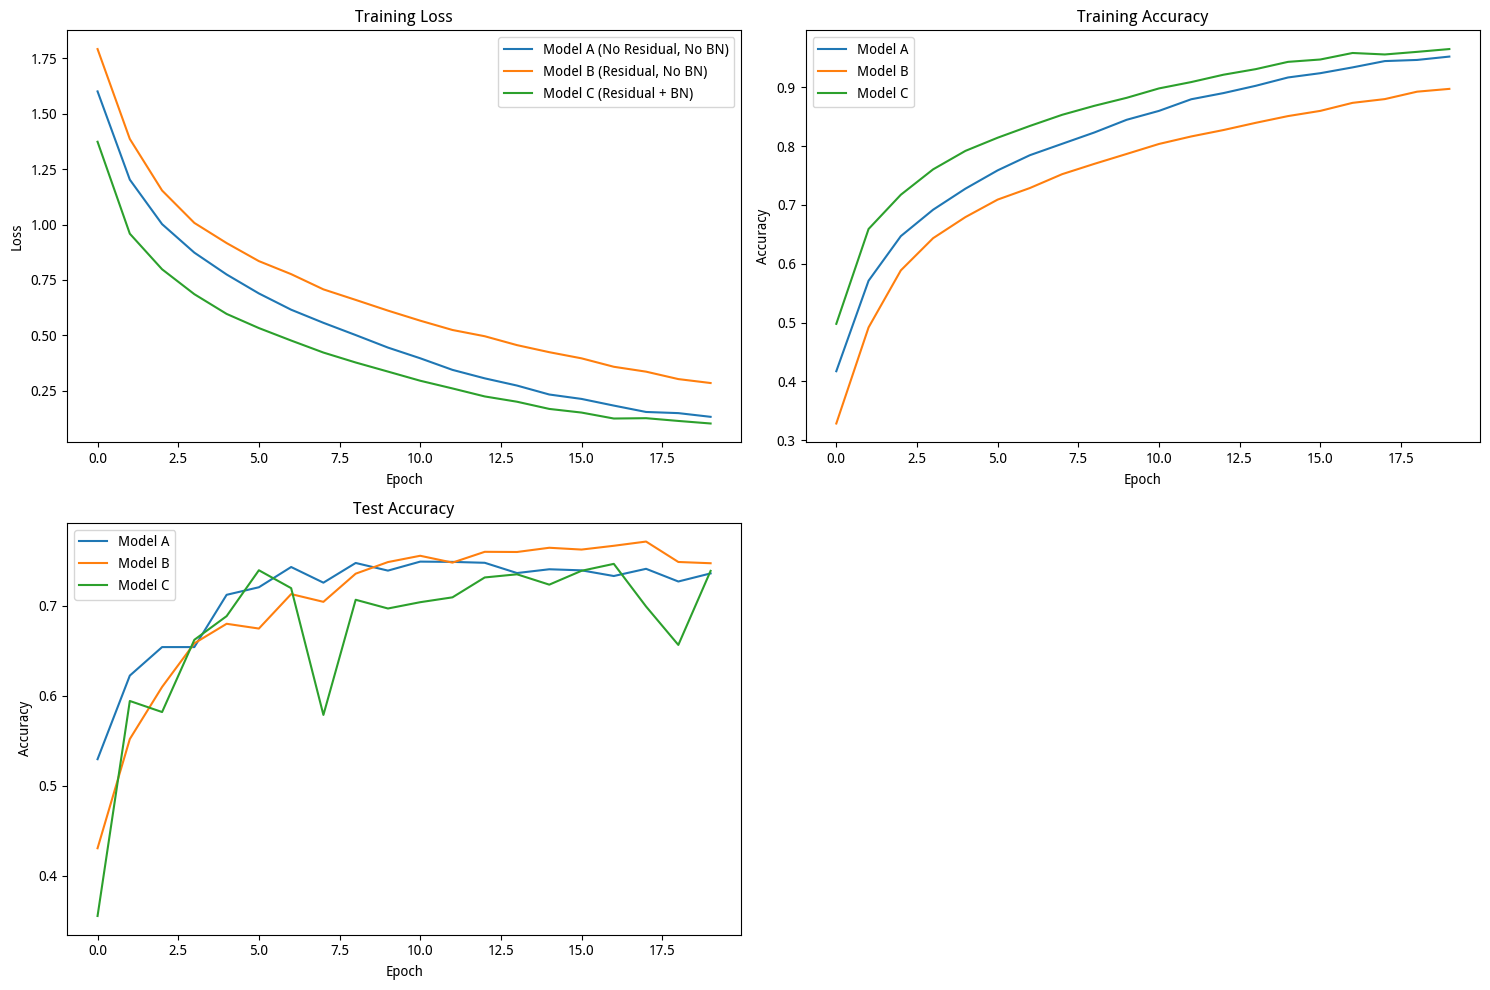

In [14]:
def plot_history(history_A, history_B, history_C):
    """可视化三种模型的训练曲线"""
    plt.figure(figsize=(15, 10))
    
    # 1. 训练损失对比
    plt.subplot(2, 2, 1)
    plt.plot(history_A.history['loss'], label='Model A (No Residual, No BN)')
    plt.plot(history_B.history['loss'], label='Model B (Residual, No BN)')
    plt.plot(history_C.history['loss'], label='Model C (Residual + BN)')
    plt.title('Training Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    
    # 2. 训练精度对比
    plt.subplot(2, 2, 2)
    plt.plot(history_A.history['accuracy'], label='Model A')
    plt.plot(history_B.history['accuracy'], label='Model B')
    plt.plot(history_C.history['accuracy'], label='Model C')
    plt.title('Training Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    
    # 3. 测试精度对比
    plt.subplot(2, 2, 3)
    plt.plot(history_A.history['val_accuracy'], label='Model A')
    plt.plot(history_B.history['val_accuracy'], label='Model B')
    plt.plot(history_C.history['val_accuracy'], label='Model C')
    plt.title('Test Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    
    plt.tight_layout()
    plt.show()

# 调用可视化函数
plot_history(history_A, history_B, history_C)